In [1]:
# Install opendatasets package
!pip install opendatasets

In [2]:
# Import opendataset libraries
import opendatasets as od

In [3]:
# Download the Dataset from kaggle
od.download('https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia?select=chest_xray')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Ronok Rahman
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:19<00:00, 125MB/s] 


In [47]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet152_Weights
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import seaborn as sns
import numpy as np
import os
import copy


In [5]:
# Select a Device
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
# Create pathway variable for the dataset
train_dir='/content/chest-xray-pneumonia/chest_xray/train'
test_dir='/content/chest-xray-pneumonia/chest_xray/test'
val_dir='/content/chest-xray-pneumonia/chest_xray/val'

In [7]:
# Image Preprocessing: Transform the train dataset
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])    # Here use image net normalization

In [8]:
# Image Preprocessing: Transform the validation dataset
val_transform=transforms.Compose([
    transforms.Resize((242,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [9]:
# Image Preprocessing: Transform the test dataset
test_transform=val_transform

In [10]:
# Load Dataset
train_dataset=datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)
val_dataset=datasets.ImageFolder(
    root=val_dir,
    transform=val_transform
)
test_dataset=datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)


In [11]:
# Creates DataLoader to feed data to model
batch_size=32
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader=DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [48]:
# Build ResNet152 model

# Load pretrained weights
weights = ResNet152_Weights.DEFAULT
model = models.resnet152(weights=weights)
# Freeze all feature layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classifier for binary classification
model.fc = nn.Linear(model.fc.in_features, 2)

# Move model to device
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 168MB/s]


In [49]:
# Creates Loss Function, Optimizer and Scheduler
# Creates Loss objective
criterion=nn.CrossEntropyLoss()

# Create optimizer object
optimizer=optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=0.0001
)

# Crreate a object of learningRate Schedule
scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5
)
# prevent gradients from becoming too small using Gradscaler
scaler=torch.amp.GradScaler('cuda')


In [50]:
# Build a Training Settings
epochs=20
patience=5
best_acc=0
counter=0

train_loss_history=[]
val_loss_history=[]
train_acc_history=[]
val_acc_history=[]

# Copy the best weights
best_weights=copy.deepcopy(model.state_dict())

In [51]:
# Train the model (ResNet152)
for epoch in range(epochs):
  print(f"\nEpoch {epoch+1}/{epochs}")

  # Train
  model.train()
  running_loss=0
  running_correct=0
  train_bar=tqdm(train_loader)

  # Load images
  for images, labels in train_bar:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()

    # Forward Pass, Loss Calculation, Backpropagation, and Optimizer Update
    with torch.amp.autocast('cuda'):
      outputs=model(images)
      loss=criterion(outputs, labels)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # Get Predicted Class
    _, preds=torch.max(outputs, 1)

    # Add Batch Loss
    running_loss+=loss.item()*images.size(0)
    # Count Correct Predictions
    running_correct+=torch.sum(preds==labels)
    # Update Progress Bar
    train_bar.set_postfix(loss=loss.item(), acc=running_correct.item()/len(train_dataset))

  # Calculate Average Training Loss and accurcay
  epoch_train_acc=running_correct.double()/len(train_dataset)
  epoch_train_loss=running_loss/len(train_dataset)

  # Validation
  model.eval()
  val_loss=0
  val_correct=0

  with torch.no_grad():
    val_bar=tqdm(val_loader)
    for images, labels in val_bar:
      images=images.to(device)
      labels=labels.to(device)
      outputs=model(images)
      loss=criterion(outputs, labels)
      _, preds=torch.max(outputs, 1)
      val_loss+=loss.item()*images.size(0)
      val_correct+=torch.sum(preds==labels)

  epoch_val_loss = val_loss/len(val_dataset)
  epoch_val_acc = val_correct.double()/len(val_dataset)

  # Update Learning Rate and Save Training History
  scheduler.step(epoch_val_loss)

  train_loss_history.append(epoch_train_loss)
  val_loss_history.append(epoch_val_loss)
  train_acc_history.append(epoch_train_acc.cpu())
  val_acc_history.append(epoch_val_acc.cpu())

  print(f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
  print(f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

  # Save the Best Model
  if epoch_val_acc>best_acc:
    best_acc=epoch_val_acc
    best_weights=copy.deepcopy(model.state_dict())
    torch.save(best_weights, 'best_weights.pth')
    counter=0
  else:
    counter+=1

  # Early Stop

  if counter >= patience:

      print("Early stopping")
      break


Epoch 1/20


100%|██████████| 1/1 [00:00<00:00,  2.71it/s]


Train Loss: 0.5036, Train Acc: 0.7391
Val Loss: 0.6306, Val Acc: 0.5000

Epoch 2/20


100%|██████████| 1/1 [00:00<00:00,  2.62it/s]


Train Loss: 0.3824, Train Acc: 0.8196
Val Loss: 0.5547, Val Acc: 0.6250

Epoch 3/20


...

Train Loss: 0.1999, Train Acc: 0.9273
Val Loss: 0.4971, Val Acc: 0.8125

Epoch 11/20


100%|██████████| 1/1 [00:00<00:00,  2.77it/s]


Train Loss: 0.1954, Train Acc: 0.9340
Val Loss: 0.4920, Val Acc: 0.7500

Epoch 12/20


100%|██████████| 1/1 [00:00<00:00,  2.71it/s]

Train Loss: 0.1886, Train Acc: 0.9291
Val Loss: 0.5056, Val Acc: 0.7500
Early stopping


In [35]:
# Load the Best Model
model.load_state_dict(best_weights)

<All keys matched successfully>

In [52]:
# Test the model
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Probability of Pneumonia (class 1)
        y_prob.extend(probabilities[:,1].cpu().numpy())

In [53]:
# Test Accuracy
test_acc=accuracy_score(y_true, y_pred)
print(f'Test Accuracy:{test_acc*100:0.2f}%')

Test Accuracy:75.80%


In [38]:
# Calssification Report
print('\nClassification Report:\n')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))


Classification Report:

              precision    recall  f1-score   support

      Normal       0.90      0.41      0.56       234
   Pneumonia       0.73      0.97      0.83       390

    accuracy                           0.76       624
   macro avg       0.81      0.69      0.70       624
weighted avg       0.79      0.76      0.73       624



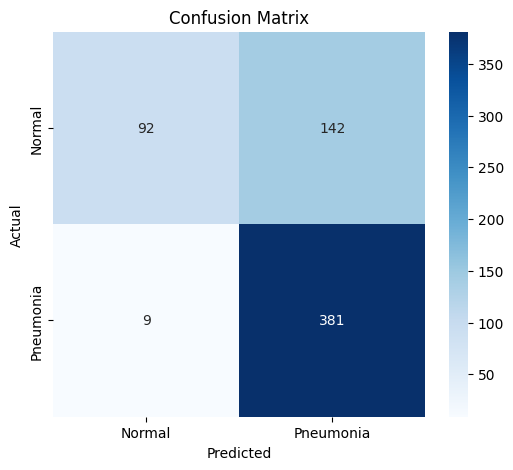

In [54]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [55]:
# Findout sensitivity and specificity
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")

Sensitivity: 97.69%
Specificity: 39.32%


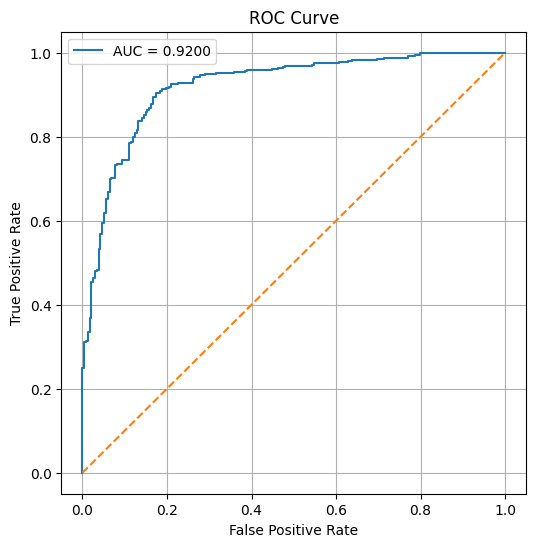

In [56]:
# Draw ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

auc_score = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [57]:
# AUC Score
print(f"AUC Score : {auc_score:.4f}")

AUC Score : 0.9200


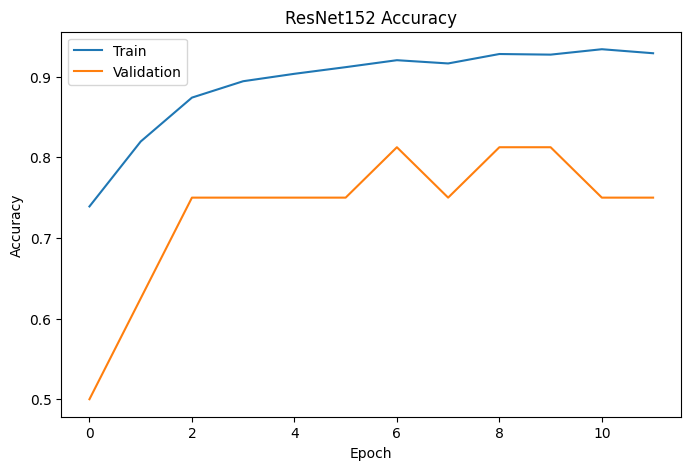

In [58]:
# Training and Validation Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(train_acc_history,label="Train")
plt.plot(val_acc_history,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet152 Accuracy")

plt.legend()

plt.show()


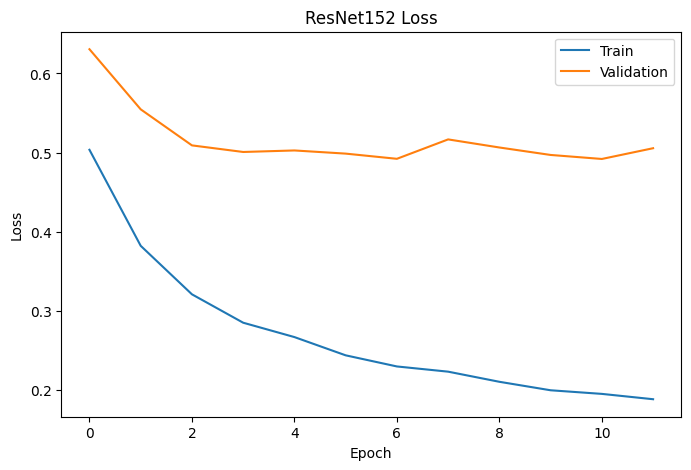

In [59]:
# Training and Validation loss Curve

plt.figure(figsize=(8,5))

plt.plot(train_loss_history,label="Train")
plt.plot(val_loss_history,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet152 Loss")

plt.legend()

plt.show()